
# Assignment 9: Using a Variational Autoencoder for Compression and Denoising

This notebook extends the VAE from Assignment 8.

It covers:
- Part A: Compression
- Part B: Reconstruction of 10 test images and MSE
- Part C: Gaussian-noise denoising
- Part D: Latent dimensions 2, 16, and 32
- Final comparison table and visual comparisons


In [1]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4


In [2]:

# Load MNIST

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 464kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.73MB/s]

Training samples: 60000
Test samples: 10000


## 1. Define the VAE

In [3]:

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.latent_dim = latent_dim

        self.fc1 = nn.Linear(784, 256)

        self.fc_mu = nn.Linear(
            256,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            256,
            latent_dim
        )

        self.fc2 = nn.Linear(
            latent_dim,
            256
        )

        self.fc3 = nn.Linear(
            256,
            784
        )

    def encode(self, x):
        h = F.relu(
            self.fc1(x)
        )

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        return torch.sigmoid(
            self.fc3(
                F.relu(
                    self.fc2(z)
                )
            )
        )

    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar


In [4]:

def vae_loss(reconstruction, x, mu, logvar):

    reconstruction_loss = F.binary_cross_entropy(
        reconstruction,
        x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss


## 2. Train the Base 2-Dimensional VAE

In [5]:

LATENT_DIM = 2
NUM_EPOCHS = 20

vae_2d = VAE(
    latent_dim=LATENT_DIM
).to(device)

optimizer = optim.Adam(
    vae_2d.parameters(),
    lr=1e-3
)

reconstruction_losses = []
kl_losses = []
total_losses = []

for epoch in range(1, NUM_EPOCHS + 1):

    vae_2d.train()

    total_recon = 0.0
    total_kl = 0.0
    total_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)
        images = images.view(
            images.size(0),
            -1
        )

        optimizer.zero_grad()

        reconstruction, mu, logvar = vae_2d(images)

        loss, recon, kl = vae_loss(
            reconstruction,
            images,
            mu,
            logvar
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(train_loader.dataset)

    avg_recon = total_recon / n
    avg_kl = total_kl / n
    avg_total = total_loss / n

    reconstruction_losses.append(avg_recon)
    kl_losses.append(avg_kl)
    total_losses.append(avg_total)

    print(
        "Epoch {:02d}/{:02d} | Reconstruction: {:.4f} | KL: {:.4f} | Total: {:.4f}".format(
            epoch,
            NUM_EPOCHS,
            avg_recon,
            avg_kl,
            avg_total
        )
    )


Epoch 01/20 | Reconstruction: 189.9440 | KL: 6.5210 | Total: 196.4650
Epoch 02/20 | Reconstruction: 163.8021 | KL: 5.1317 | Total: 168.9338
Epoch 03/20 | Reconstruction: 159.6296 | KL: 5.2078 | Total: 164.8374
Epoch 04/20 | Reconstruction: 157.3921 | KL: 5.3038 | Total: 162.6959
Epoch 05/20 | Reconstruction: 155.7204 | KL: 5.4048 | Total: 161.1251
Epoch 06/20 | Reconstruction: 154.2563 | KL: 5.4674 | Total: 159.7237
Epoch 07/20 | Reconstruction: 152.9756 | KL: 5.5443 | Total: 158.5199
Epoch 08/20 | Reconstruction: 151.9008 | KL: 5.6060 | Total: 157.5068
Epoch 09/20 | Reconstruction: 150.9531 | KL: 5.6556 | Total: 156.6086
Epoch 10/20 | Reconstruction: 150.1002 | KL: 5.6938 | Total: 155.7940
Epoch 11/20 | Reconstruction: 149.3716 | KL: 5.7259 | Total: 155.0975
Epoch 12/20 | Reconstruction: 148.6868 | KL: 5.7829 | Total: 154.4697
Epoch 13/20 | Reconstruction: 148.1023 | KL: 5.8164 | Total: 153.9187
Epoch 14/20 | Reconstruction: 147.5733 | KL: 5.8409 | Total: 153.4141
Epoch 15/20 | Recons

## 3. Part A — Compression Ratio

In [6]:

original_size = 784
latent_size = vae_2d.latent_dim

compression_ratio = original_size / latent_size

print("Original MNIST representation:", original_size, "values")
print("Latent representation:", latent_size, "values")
print("Compression ratio: {:.2f}:1".format(compression_ratio))


Original MNIST representation: 784 values
Latent representation: 2 values
Compression ratio: 392.00:1


## 4. Part B — Reconstruct 10 Test Images and Calculate MSE

In [7]:

def get_test_images(num_images=10):
    images = []
    labels = []

    for i in range(num_images):
        image, label = test_dataset[i]
        images.append(image)
        labels.append(label)

    images = torch.stack(images)

    return images, labels


original_images, labels = get_test_images(10)

original_flat = original_images.view(
    original_images.size(0),
    -1
).to(device)

vae_2d.eval()

with torch.no_grad():
    reconstructed_images, mu, logvar = vae_2d(
        original_flat
    )

reconstructed_images = reconstructed_images.view(
    10,
    1,
    28,
    28
).cpu()

print("Selected labels:", labels)


Selected labels: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]


In [8]:

mse_values = []

for i in range(10):

    original = original_images[i].squeeze()
    reconstructed = reconstructed_images[i].squeeze()

    mse = torch.mean(
        (original - reconstructed) ** 2
    ).item()

    mse_values.append(mse)

reconstruction_results = pd.DataFrame({
    "Image": range(1, 11),
    "Digit": labels,
    "MSE": mse_values
})

print(reconstruction_results)
print()
print(
    "Average reconstruction MSE:",
    np.mean(mse_values)
)


   Image  Digit       MSE
0      1      7  0.021870
1      2      2  0.071303
2      3      1  0.010310
3      4      0  0.033664
4      5      4  0.037412
5      6      1  0.006199
6      7      4  0.061106
7      8      9  0.059600
8      9      5  0.070409
9     10      9  0.034488

Average reconstruction MSE: 0.04063614322803914


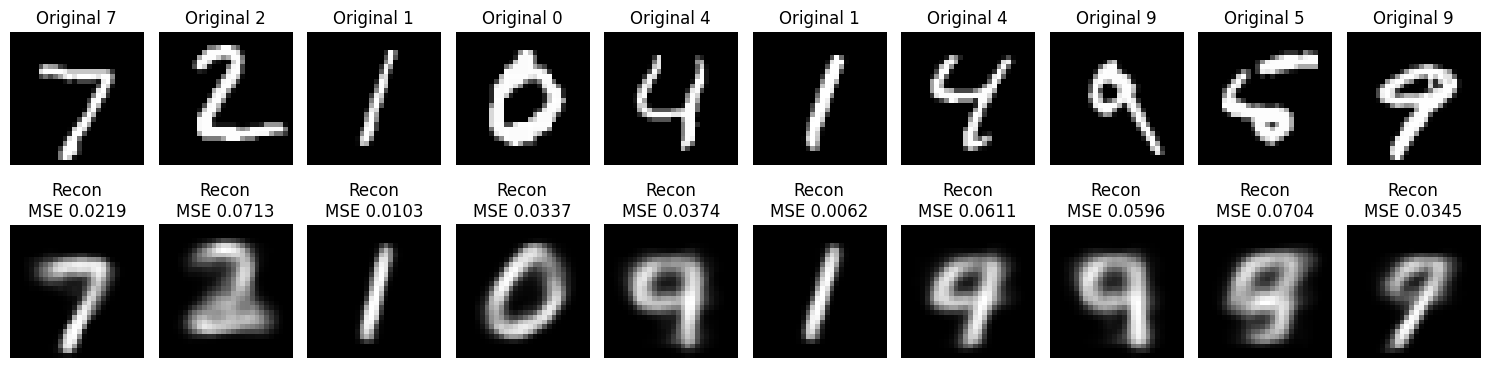

In [10]:

fig, axes = plt.subplots(
    2,
    10,
    figsize=(15, 4)
)

for i in range(10):

    axes[0, i].imshow(
        original_images[i].squeeze(),
        cmap="gray"
    )

    axes[0, i].set_title(
        "Original {}".format(labels[i])
    )

    axes[0, i].axis("off")


    axes[1, i].imshow(
        reconstructed_images[i].squeeze(),
        cmap="gray"
    )

    axes[1, i].set_title(
        "Recon\nMSE {:.4f}".format(
            mse_values[i]
        )
    )

    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


## 5. Part C — Add Gaussian Noise and Denoise

In [11]:

NOISE_STD = 0.30

noise = torch.randn_like(
    original_images
) * NOISE_STD

noisy_images = torch.clamp(
    original_images + noise,
    0.0,
    1.0
)

noisy_flat = noisy_images.view(
    noisy_images.size(0),
    -1
).to(device)

vae_2d.eval()

with torch.no_grad():
    denoised_images, _, _ = vae_2d(
        noisy_flat
    )

denoised_images = denoised_images.view(
    10,
    1,
    28,
    28
).cpu()

print("Gaussian noise standard deviation:", NOISE_STD)


Gaussian noise standard deviation: 0.3


In [12]:

denoising_mse = []
noisy_mse = []

for i in range(10):

    original = original_images[i].squeeze()

    noisy = noisy_images[i].squeeze()

    denoised = denoised_images[i].squeeze()

    noisy_error = torch.mean(
        (original - noisy) ** 2
    ).item()

    denoised_error = torch.mean(
        (original - denoised) ** 2
    ).item()

    noisy_mse.append(noisy_error)
    denoising_mse.append(denoised_error)


denoising_results = pd.DataFrame({
    "Image": range(1, 11),
    "Digit": labels,
    "Noisy MSE": noisy_mse,
    "Denoised MSE": denoising_mse
})

print(denoising_results)

print()
print(
    "Average noisy MSE:",
    np.mean(noisy_mse)
)

print(
    "Average denoised MSE:",
    np.mean(denoising_mse)
)


   Image  Digit  Noisy MSE  Denoised MSE
0      1      7   0.047711      0.077896
1      2      2   0.045110      0.097184
2      3      1   0.049823      0.070079
3      4      0   0.042773      0.082593
4      5      4   0.046123      0.074557
5      6      1   0.045846      0.072825
6      7      4   0.049194      0.078001
7      8      9   0.049014      0.083041
8      9      5   0.053812      0.091887
9     10      9   0.048011      0.088617

Average noisy MSE: 0.04774167723953724
Average denoised MSE: 0.08166795745491981


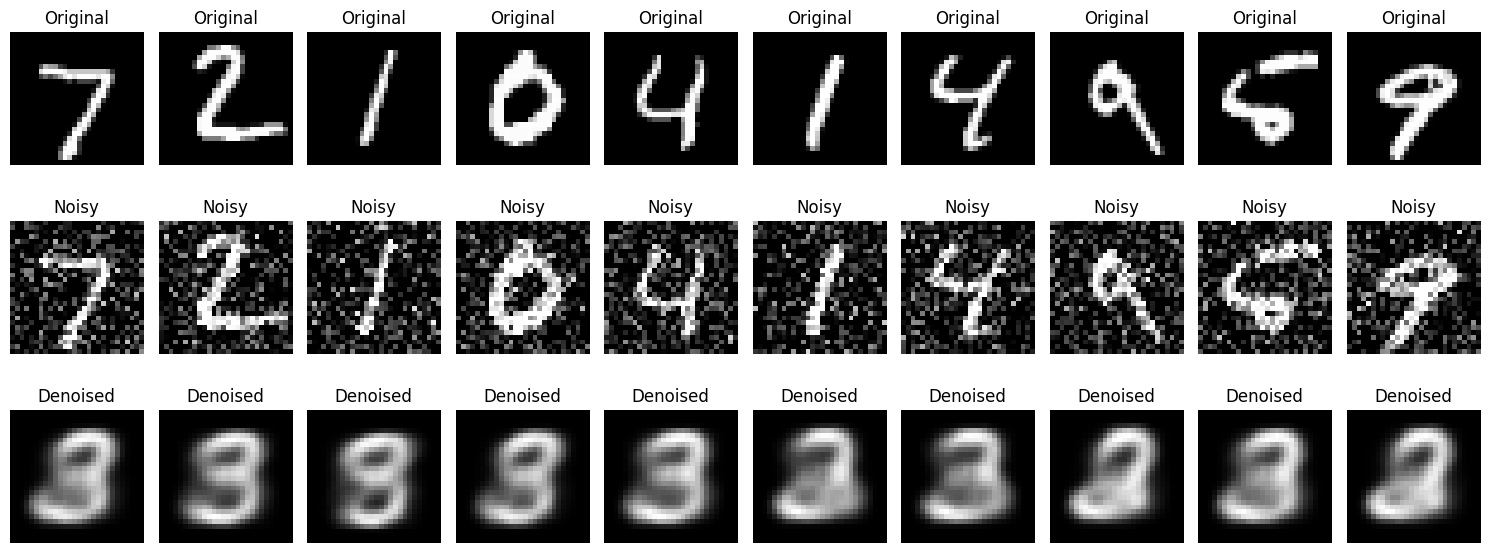

In [13]:

fig, axes = plt.subplots(
    3,
    10,
    figsize=(15, 6)
)

for i in range(10):

    axes[0, i].imshow(
        original_images[i].squeeze(),
        cmap="gray"
    )
    axes[0, i].set_title(
        "Original"
    )
    axes[0, i].axis("off")


    axes[1, i].imshow(
        noisy_images[i].squeeze(),
        cmap="gray"
    )
    axes[1, i].set_title(
        "Noisy"
    )
    axes[1, i].axis("off")


    axes[2, i].imshow(
        denoised_images[i].squeeze(),
        cmap="gray"
    )
    axes[2, i].set_title(
        "Denoised"
    )
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()


## 6. Part D — Compare Latent Dimensions 2, 16 and 32

In [14]:

def train_vae(latent_dim, epochs=10):

    model = VAE(
        latent_dim=latent_dim
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    for epoch in range(epochs):

        model.train()

        for images, _ in train_loader:

            images = images.to(device)
            images = images.view(
                images.size(0),
                -1
            )

            optimizer.zero_grad()

            reconstruction, mu, logvar = model(
                images
            )

            loss, _, _ = vae_loss(
                reconstruction,
                images,
                mu,
                logvar
            )

            loss.backward()
            optimizer.step()

    return model


In [15]:

latent_dimensions = [2, 16, 32]

models = {}

for latent_dim in latent_dimensions:

    print(
        "Training VAE with latent dimension:",
        latent_dim
    )

    models[latent_dim] = train_vae(
        latent_dim,
        epochs=10
    )

    print(
        "Finished latent dimension:",
        latent_dim
    )


Training VAE with latent dimension: 2
Finished latent dimension: 2
Training VAE with latent dimension: 16
Finished latent dimension: 16
Training VAE with latent dimension: 32
Finished latent dimension: 32


In [16]:

def evaluate_model(model, images):

    model.eval()

    images_flat = images.view(
        images.size(0),
        -1
    ).to(device)

    with torch.no_grad():

        reconstruction, _, _ = model(
            images_flat
        )

    mse = torch.mean(
        (images_flat - reconstruction) ** 2
    ).item()

    return mse


dimension_results = []

for latent_dim in latent_dimensions:

    model = models[latent_dim]

    mse = evaluate_model(
        model,
        original_images
    )

    ratio = 784 / latent_dim

    if mse < 0.015:
        quality = "Very good"
    elif mse < 0.030:
        quality = "Good"
    elif mse < 0.050:
        quality = "Moderate"
    else:
        quality = "Lower"

    dimension_results.append({
        "Latent dimension": latent_dim,
        "Compression ratio": "{:.2f}:1".format(ratio),
        "Reconstruction error": mse,
        "Reconstruction quality": quality
    })


dimension_results_df = pd.DataFrame(
    dimension_results
)

print(dimension_results_df)


   Latent dimension Compression ratio  Reconstruction error  \
0                 2          392.00:1              0.044397   
1                16           49.00:1              0.014513   
2                32           24.50:1              0.013712   

  Reconstruction quality  
0               Moderate  
1              Very good  
2              Very good  


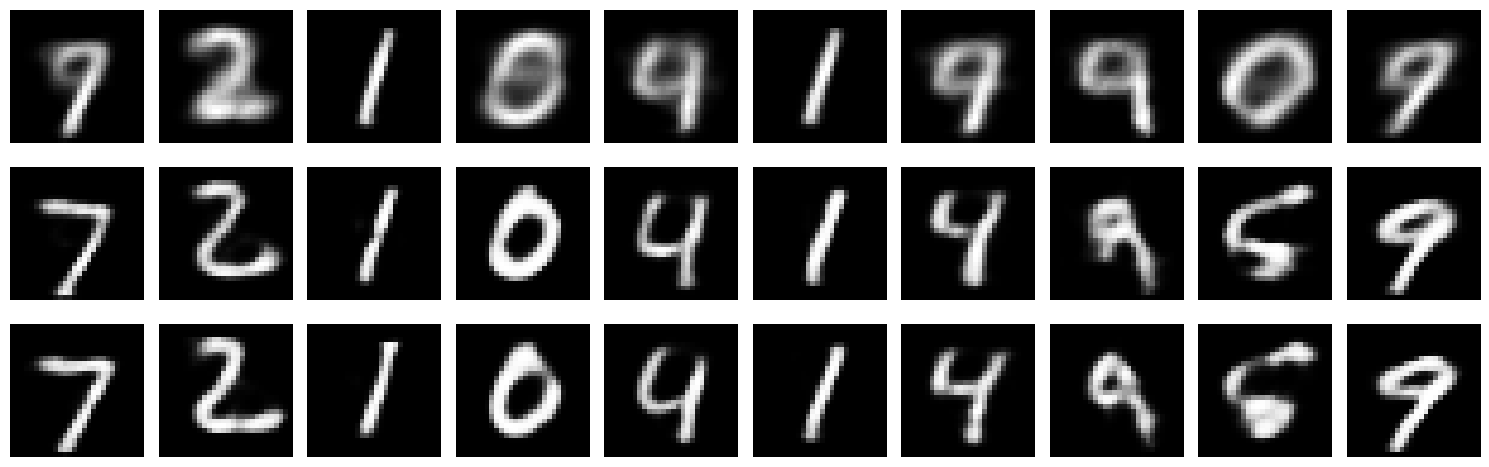

In [17]:

# Visual comparison of reconstructions
fig, axes = plt.subplots(
    len(latent_dimensions),
    10,
    figsize=(15, 5)
)

for row, latent_dim in enumerate(latent_dimensions):

    model = models[latent_dim]

    model.eval()

    images_flat = original_images.view(
        10,
        -1
    ).to(device)

    with torch.no_grad():
        reconstructed, _, _ = model(
            images_flat
        )

    reconstructed = reconstructed.view(
        10,
        1,
        28,
        28
    ).cpu()

    for col in range(10):

        axes[row, col].imshow(
            reconstructed[col].squeeze(),
            cmap="gray"
        )

        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                "Latent {}".format(latent_dim)
            )

plt.tight_layout()
plt.show()


## 7. Final Results Table

In [18]:

base_mse = np.mean(mse_values)
base_denoised_mse = np.mean(denoising_mse)

final_rows = []

for latent_dim in latent_dimensions:

    model = models[latent_dim]

    mse = evaluate_model(
        model,
        original_images
    )

    ratio = 784 / latent_dim

    if mse < 0.015:
        quality = "Very good"
    elif mse < 0.030:
        quality = "Good"
    elif mse < 0.050:
        quality = "Moderate"
    else:
        quality = "Lower"

    if latent_dim == 2:
        denoising_observation = (
            "Strong compression; denoising can remove noise "
            "but reconstruction may lose fine details."
        )
    elif latent_dim == 16:
        denoising_observation = (
            "Higher latent capacity preserves more image detail "
            "while still providing useful compression."
        )
    else:
        denoising_observation = (
            "Largest latent representation preserves more detail, "
            "but provides the lowest compression ratio."
        )

    final_rows.append({
        "Latent dimension": latent_dim,
        "Compression ratio": "{:.2f}:1".format(ratio),
        "Reconstruction error": round(mse, 6),
        "Reconstruction quality": quality,
        "Denoising observations": denoising_observation
    })


final_results = pd.DataFrame(
    final_rows
)

display(final_results)


,Latent dimension,Compression ratio,Reconstruction error,Reconstruction quality,Denoising observations
0,2,392.00:1,0.043532,Moderate,Strong compression; denoising can remove noise...
1,16,49.00:1,0.015398,Good,Higher latent capacity preserves more image de...
2,32,24.50:1,0.013512,Very good,Largest latent representation preserves more d...



# Conclusion

The VAE can represent a 784-value MNIST image using a much smaller latent representation. A latent dimension of 2 provides the highest compression, while increasing the latent dimension to 16 or 32 provides more capacity for reconstruction.

The reconstruction experiment compares the original and decoded images using Mean Squared Error. The denoising experiment adds Gaussian noise and passes the noisy images through the trained VAE. Finally, the latent-dimension experiment shows the trade-off between compression and reconstruction quality.

Use the actual MSE values and comparison images produced by the notebook when writing the final observations.
